<a href="https://colab.research.google.com/github/BumGyo/2026-1_CV/blob/main/3%EC%A3%BC%EC%B0%A8_%EA%B3%BC%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Running Experiment A: Loss Functions...


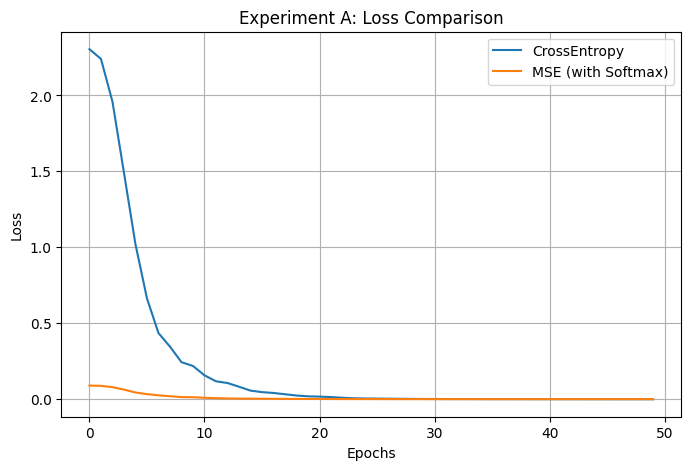


Running Experiment B: Activation Functions...


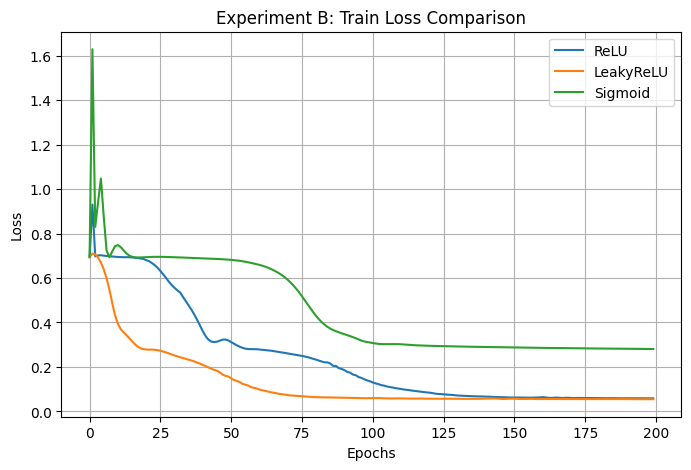

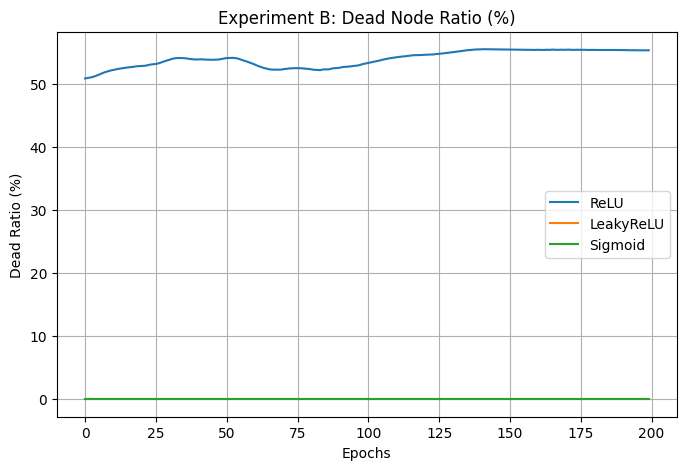


Running Experiment C: Optimizers...


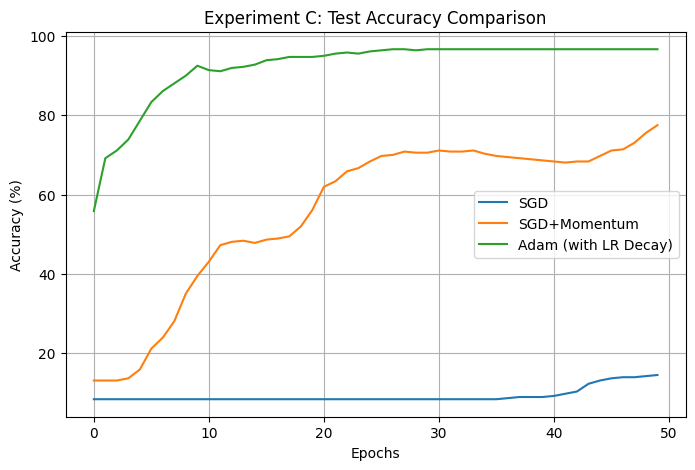

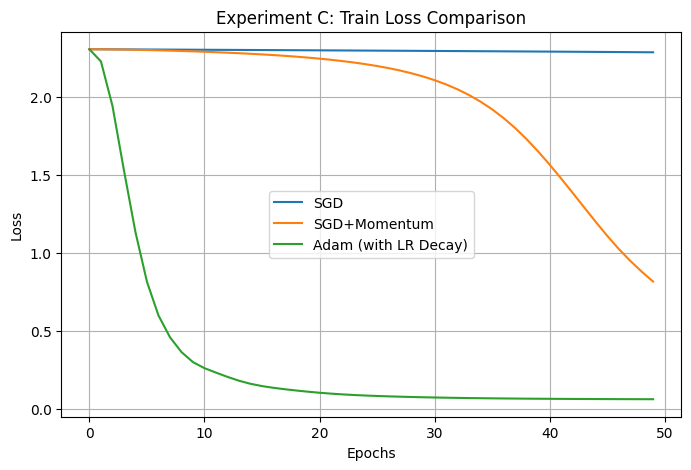

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import load_digits, make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. 데이터셋 준비 (Digits, Make_Moons)
# ==========================================
def get_digits_data():
    digits = load_digits()
    X_train, X_test, y_train, y_test = train_test_split(digits.data, digits.target, test_size=0.2, random_state=42)
    scaler = StandardScaler()
    X_train = torch.tensor(scaler.fit_transform(X_train), dtype=torch.float32)
    X_test = torch.tensor(scaler.transform(X_test), dtype=torch.float32)
    y_train = torch.tensor(y_train, dtype=torch.long)
    y_test = torch.tensor(y_test, dtype=torch.long)
    return X_train, X_test, y_train, y_test

def get_moons_data():
    X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    X_train = torch.tensor(X_train, dtype=torch.float32)
    X_test = torch.tensor(X_test, dtype=torch.float32)
    y_train = torch.tensor(y_train, dtype=torch.long)
    y_test = torch.tensor(y_test, dtype=torch.long)
    return X_train, X_test, y_train, y_test

# ==========================================
# 2. MLP 모델 정의 (Activation 커스텀 가능)
# ==========================================
class CustomMLP(nn.Module):
    def __init__(self, input_size, num_classes, activation_name='relu'):
        super(CustomMLP, self).__init__()

        # 활성화 함수 매핑
        activations = {
            'relu': nn.ReLU(),
            'leaky_relu': nn.LeakyReLU(negative_slope=0.01),
            'sigmoid': nn.Sigmoid()
        }
        self.act = activations[activation_name]

        self.fc1 = nn.Linear(input_size, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, num_classes)

        # 가중치 초기화 (Dead ReLU 유도를 위해 작게 설정)
        nn.init.normal_(self.fc1.weight, mean=0, std=0.01)
        nn.init.normal_(self.fc2.weight, mean=0, std=0.01)

        # 중간 Layer의 활성화 값을 저장하기 위한 딕셔너리
        self.activations_dict = {}

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        self.activations_dict['hidden1'] = x.detach().clone() # 히트맵/Dead ReLU 분석용

        x = self.fc2(x)
        x = self.act(x)
        self.activations_dict['hidden2'] = x.detach().clone()

        logits = self.fc3(x)
        return logits

# ==========================================
# 3. 범용 학습 및 평가 함수
# ==========================================
def train_and_evaluate(model, X_train, y_train, X_test, y_test,
                       loss_type='ce', opt_type='adam', lr=0.01, epochs=50, use_scheduler=False):

    # 손실 함수 설정 (실험 A 대응)
    if loss_type == 'ce':
        loss_fn = nn.CrossEntropyLoss()
    elif loss_type == 'mse':
        loss_fn = nn.MSELoss()
        # MSE를 위해 정답을 One-Hot Vector로 변환
        num_classes = model.fc3.out_features
        y_train_onehot = torch.nn.functional.one_hot(y_train, num_classes=num_classes).float()
        y_test_onehot = torch.nn.functional.one_hot(y_test, num_classes=num_classes).float()

    # Optimizer 설정 (실험 C 대응)
    if opt_type == 'sgd':
        optimizer = optim.SGD(model.parameters(), lr=lr)
    elif opt_type == 'momentum':
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    elif opt_type == 'adam':
        optimizer = optim.Adam(model.parameters(), lr=lr)

    # Scheduler 설정
    if use_scheduler:
        scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)

    history = {'train_loss': [], 'test_acc': [], 'dead_relu_ratio': []}

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train)

        if loss_type == 'mse':
            outputs = torch.softmax(outputs, dim=1) # MSE 사용 시 명시적 Softmax
            loss = loss_fn(outputs, y_train_onehot)
        else:
            loss = loss_fn(outputs, y_train)

        loss.backward()
        optimizer.step()

        if use_scheduler:
            scheduler.step()

        # 평가 및 기록
        model.eval()
        with torch.no_grad():
            test_outputs = model(X_test)
            preds = torch.argmax(test_outputs, dim=1)
            acc = (preds == y_test).float().mean().item() * 100

            # Dead ReLU 비율 측정 (Hidden 1 기준)
            acts = model.activations_dict['hidden1']
            dead_ratio = (acts == 0).float().mean().item() * 100

            history['train_loss'].append(loss.item())
            history['test_acc'].append(acc)
            history['dead_relu_ratio'].append(dead_ratio)

    return history

# ==========================================
# 4. 시각화 도우미 함수
# ==========================================
def plot_results(histories, labels, title, ylabel, key):
    plt.figure(figsize=(8, 5))
    for hist, label in zip(histories, labels):
        plt.plot(hist[key], label=label)
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True)
    plt.show()

# ==========================================
# 5. 실험 실행 파트
# ==========================================
if __name__ == "__main__":
    # 데이터 로드
    X_train_d, X_test_d, y_train_d, y_test_d = get_digits_data()
    X_train_m, X_test_m, y_train_m, y_test_m = get_moons_data()

    # [실험 A] CrossEntropy vs MSE
    print("Running Experiment A: Loss Functions...")
    model_ce = CustomMLP(input_size=64, num_classes=10, activation_name='relu')
    hist_ce = train_and_evaluate(model_ce, X_train_d, y_train_d, X_test_d, y_test_d,
                                 loss_type='ce', opt_type='adam', lr=0.01, epochs=50)

    model_mse = CustomMLP(input_size=64, num_classes=10, activation_name='relu')
    hist_mse = train_and_evaluate(model_mse, X_train_d, y_train_d, X_test_d, y_test_d,
                                  loss_type='mse', opt_type='adam', lr=0.01, epochs=50)

    plot_results([hist_ce, hist_mse], ['CrossEntropy', 'MSE (with Softmax)'],
                 'Experiment A: Loss Comparison', 'Loss', 'train_loss')

    # [실험 B] 활성화 함수 비교 (ReLU vs LeakyReLU vs Sigmoid)
    print("\nRunning Experiment B: Activation Functions...")
    model_relu = CustomMLP(input_size=2, num_classes=2, activation_name='relu')
    hist_relu = train_and_evaluate(model_relu, X_train_m, y_train_m, X_test_m, y_test_m,
                                   loss_type='ce', opt_type='adam', lr=0.01, epochs=200)

    model_leaky = CustomMLP(input_size=2, num_classes=2, activation_name='leaky_relu')
    hist_leaky = train_and_evaluate(model_leaky, X_train_m, y_train_m, X_test_m, y_test_m,
                                    loss_type='ce', opt_type='adam', lr=0.01, epochs=200)

    model_sig = CustomMLP(input_size=2, num_classes=2, activation_name='sigmoid')
    hist_sig = train_and_evaluate(model_sig, X_train_m, y_train_m, X_test_m, y_test_m,
                                  loss_type='ce', opt_type='adam', lr=0.01, epochs=200)

    plot_results([hist_relu, hist_leaky, hist_sig], ['ReLU', 'LeakyReLU', 'Sigmoid'],
                 'Experiment B: Train Loss Comparison', 'Loss', 'train_loss')

    plot_results([hist_relu, hist_leaky, hist_sig], ['ReLU', 'LeakyReLU', 'Sigmoid'],
                 'Experiment B: Dead Node Ratio (%)', 'Dead Ratio (%)', 'dead_relu_ratio')

    # [실험 C] 최적화 알고리즘 비교 (SGD vs SGD+Momentum vs Adam)
    print("\nRunning Experiment C: Optimizers...")
    model_sgd = CustomMLP(input_size=64, num_classes=10, activation_name='relu')
    hist_sgd = train_and_evaluate(model_sgd, X_train_d, y_train_d, X_test_d, y_test_d,
                                  loss_type='ce', opt_type='sgd', lr=0.05, epochs=50)

    model_mom = CustomMLP(input_size=64, num_classes=10, activation_name='relu')
    hist_mom = train_and_evaluate(model_mom, X_train_d, y_train_d, X_test_d, y_test_d,
                                  loss_type='ce', opt_type='momentum', lr=0.05, epochs=50)

    model_adam = CustomMLP(input_size=64, num_classes=10, activation_name='relu')
    hist_adam = train_and_evaluate(model_adam, X_train_d, y_train_d, X_test_d, y_test_d,
                                   loss_type='ce', opt_type='adam', lr=0.01, epochs=50, use_scheduler=True)

    plot_results([hist_sgd, hist_mom, hist_adam], ['SGD', 'SGD+Momentum', 'Adam (with LR Decay)'],
                 'Experiment C: Test Accuracy Comparison', 'Accuracy (%)', 'test_acc')

    plot_results([hist_sgd, hist_mom, hist_adam], ['SGD', 'SGD+Momentum', 'Adam (with LR Decay)'],
                 'Experiment C: Train Loss Comparison', 'Loss', 'train_loss')